# Best Two Markets to Advertise In

The gola of this project is to find best markets to advertise the different new product ranges.
- Most of the courses are on web and mobile development, but other domains, like data science,game development, etc are also focused for advertisement.
- At the end of the anlysis, we will have `2` best market to advertise our product in.


## Loading the Data 

In [1]:
# import necessary module
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt

In [2]:
# Read the Dataset in pandas Dataframe
code = pd.read_csv('../../dataset/2017-fCC-New-Coders-Survey-Data.csv')

# print the first 5 rows
code.head()

/tmp/ipykernel_212/2296695304.py:2: DtypeWarning: Columns (17,62) have mixed types. Specify dtype option on import or set low_memory=False.
  code = pd.read_csv('2017-fCC-New-Coders-Survey-Data.csv')


,Age,AttendedBootcamp,BootcampFinish,BootcampLoanYesNo,BootcampName,BootcampRecommend,ChildrenNumber,CityPopulation,CodeEventConferences,CodeEventDjangoGirls,...,YouTubeFCC,YouTubeFunFunFunction,YouTubeGoogleDev,YouTubeLearnCode,YouTubeLevelUpTuts,YouTubeMIT,YouTubeMozillaHacks,YouTubeOther,YouTubeSimplilearn,YouTubeTheNewBoston
0,27.0,0.0,NaN,NaN,NaN,NaN,NaN,more than 1 million,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,34.0,0.0,NaN,NaN,NaN,NaN,NaN,"less than 100,000",NaN,NaN,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,21.0,0.0,NaN,NaN,NaN,NaN,NaN,more than 1 million,NaN,NaN,...,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN
3,26.0,0.0,NaN,NaN,NaN,NaN,NaN,"between 100,000 and 1 million",NaN,NaN,...,1.0,1.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
4,20.0,0.0,NaN,NaN,NaN,NaN,NaN,"between 100,000 and 1 million",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# checking the shape of dataset
code.shape

(18175, 136)

- This survey collects 48 different question from the developers who start coding less than 5 years.
- This dataset is good starting point because our goal is to find the overall interest of new developers and we can cater them effectively if we know their preferrred coding language, experince, and who they watch to learn coding.
- The dataset can be downloaded [2017-new-coders-survey](https://github.com/freeCodeCamp/2017-new-coder-survey)

## Checking for Sample Representativity

In [4]:
# frequency distribution table for JobRoleInterest Column
frequency = code['JobRoleInterest'].value_counts(normalize = True).sort_values() * 100
frequency


JobRoleInterest
Back-End Web Developer, Full-Stack Web Developer,   Product Manager,   Front-End Web Developer,   Mobile Developer                                             0.014302
  Front-End Web Developer, Game Developer,   Mobile Developer, Back-End Web Developer, Full-Stack Web Developer                                                0.014302
Back-End Web Developer, Data Engineer,   Mobile Developer, Game Developer,   User Experience Designer, Full-Stack Web Developer,   Front-End Web Developer     0.014302
  Product Manager, Data Engineer, Full-Stack Web Developer,   Data Scientist                                                                                   0.014302
Information Security,   Product Manager, Back-End Web Developer, Full-Stack Web Developer,   Data Scientist, Data Engineer                                     0.014302
                                                                                                                                                

In [5]:
frequency.tail()

JobRoleInterest
  Mobile Developer            1.673341
Back-End Web Developer        2.030892
  Data Scientist              2.173913
  Front-End Web Developer     6.435927
Full-Stack Web Developer     11.770595
Name: proportion, dtype: float64

### split the interest group of coder

In [6]:
# first let's drop the na value
no_null_code = code['JobRoleInterest'].dropna()

# split the coder interest 
split_code = no_null_code.str.split(',')
split_code_interest = split_code.apply(lambda x: len(x))
split_code_interest.value_counts(normalize = True) * 100

JobRoleInterest
1     31.650458
3     15.889588
4     15.217391
5     12.042334
2     10.883867
6      6.721968
7      3.861556
8      1.759153
9      0.986842
10     0.471968
12     0.300343
11     0.185927
13     0.028604
Name: proportion, dtype: float64

We analyze that `31%` coder have already decided what job opportunity they want to grab.
Since our focus is to sell web and app development course. we will now analyze, how many of them prefer career path in these roles.


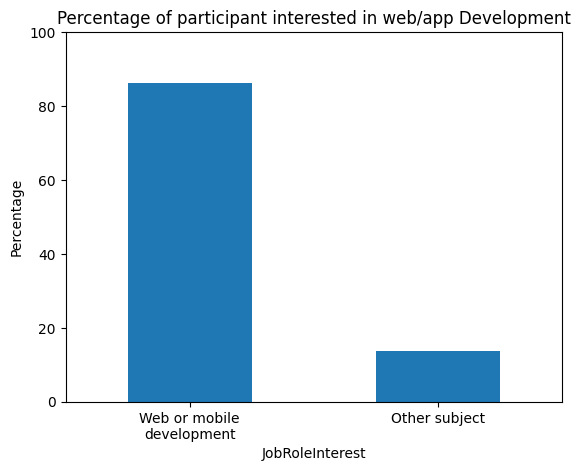

In [7]:
web_app_dev = no_null_code.str.contains('Web Developer|Mobile Developer')

freq_table = web_app_dev.value_counts(normalize = True) * 100
freq_table.plot.bar()
plt.title('Percentage of participant interested in web/app Development')
plt.ylabel('Percentage')
plt.xticks([0,1],['Web or mobile\ndevelopment', 'Other subject'],
           rotation = 0) # the initial xtick labels were True and False
plt.ylim([0,100])
plt.show()


About `85%` of people are interested in Web and mobile development.

## New Coders - Locations and Densities

Our goal is finding the two best countries to advertise the products.
- One indicator of a good market is the number of potential customers

In [8]:
# Drop all the rows where participants didn't answer what role they are interested in.
interest_no_null = code[code['JobRoleInterest'].notnull()].copy()

# Generate frequency table for CountryLive variable
absolute_freq = interest_no_null['CountryLive'].value_counts()
print(absolute_freq)

CountryLive
United States of America    3125
India                        528
United Kingdom               315
Canada                       260
Poland                       131
                            ... 
Vanuatu                        1
Anguilla                       1
Mozambique                     1
Nicaragua                      1
Gambia                         1
Name: count, Length: 137, dtype: int64


In [9]:
# Let's see the frequency table in relative terms.
relative_freq = interest_no_null['CountryLive'].value_counts(normalize = True) * 100
print(relative_freq)

CountryLive
United States of America    45.700497
India                        7.721556
United Kingdom               4.606610
Canada                       3.802281
Poland                       1.915765
                              ...    
Vanuatu                      0.014624
Anguilla                     0.014624
Mozambique                   0.014624
Nicaragua                    0.014624
Gambia                       0.014624
Name: proportion, Length: 137, dtype: float64


United States of America have highest number of new participants covering `45.7%` of total. The next country represent `7.7%` which show significant difference compared to usa. We we choose `USA` and `India` for advertisement it will cover `54%` of the participants.
We need to do further analysis to choose the best two markets.

## Spending Money for Learning
We will narrow down our analysis to only four countries: the US, India, the United Kingdom, and Canada.
- These are the countries having the highest absolute frequencies in our sample, which means we have a decent amount of data for each.


In [10]:
# replace all the value of 0 with 1 in MonthsProgramming column
interest_no_null['MonthsProgramming'] = interest_no_null['MonthsProgramming'].replace(0,1)

# calculate money spent per month by user.
interest_no_null['money_spend'] = interest_no_null['MoneyForLearning'] / interest_no_null['MonthsProgramming']

# find out now many null value are in column 
print(interest_no_null['money_spend'].isnull().sum())

# We keep only rows that don't have null value for the new column
interest_no_null = interest_no_null[interest_no_null['money_spend'].notnull()].copy()

# Remove any rows that have null value in CountryLive column
interest_no_null = interest_no_null[interest_no_null['CountryLive'].notnull()].copy()

675


In [11]:
# checking the shape of dataframe
interest_no_null.shape

(6212, 137)

In [12]:
# checking if we still have enough data for analysis
interest_no_null['CountryLive'].value_counts()

CountryLive
United States of America    2933
India                        463
United Kingdom               279
Canada                       240
Poland                       122
                            ... 
Vanuatu                        1
Anguilla                       1
Mozambique                     1
Nicaragua                      1
Gambia                         1
Name: count, Length: 131, dtype: int64

In [13]:
# Group by the data by country to find how much moneya student spend on average.

groupby_data = interest_no_null.groupby('CountryLive')

mean_of_country = groupby_data['money_spend'].mean(numeric_only = True)
print(mean_of_country[['United States of America',
                            'India', 'United Kingdom',
                            'Canada']])

CountryLive
United States of America    227.997996
India                       135.100982
United Kingdom               45.534443
Canada                      113.510961
Name: money_spend, dtype: float64


Although, the gpd of U.K and Canada is much higher than india. We still see that indian developer spend more than U.K and Canada developer.
Maybe the data is not representative or it might be True.

## Dealing with Extreme Outliers

Generating four box plots on the same figure to visualize for each country

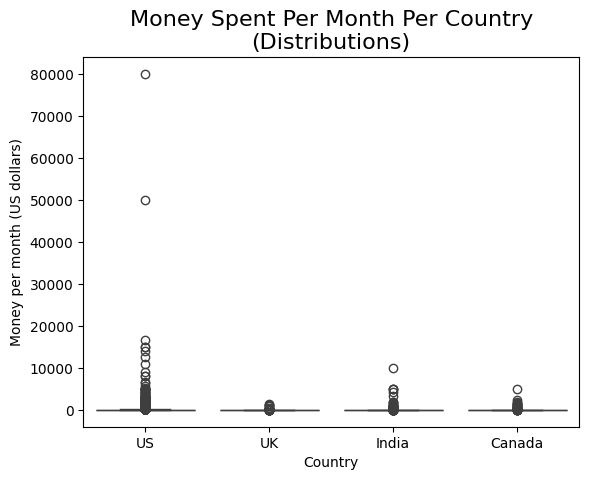

In [14]:
import seaborn as sns
only_4 = interest_no_null[interest_no_null['CountryLive'].isin(['United States of America','United Kingdom', 'India','Canada'])]

sns.boxplot( y = 'money_spend', x = 'CountryLive', data = only_4)
plt.title('Money Spent Per Month Per Country\n(Distributions)',
         fontsize = 16)
plt.ylabel('Money per month (US dollars)')
plt.xlabel('Country')
plt.xticks(range(4), ['US', 'UK', 'India', 'Canada']) # avoids tick labels overlap
plt.show()

India have more outliers compared to uk and canada. Also, two user in america has unusual spending of more than 20000 per month.

In [15]:
# Isolate only those participants who spend less than 20000 per month
interest_no_null = interest_no_null[interest_no_null['money_spend'] < 20000]

In [16]:
# Recompute the mean of 4 contry to plot the graph.

groupby_data = interest_no_null.groupby('CountryLive')

mean_of_country = groupby_data['money_spend'].mean(numeric_only = True)
print(mean_of_country[['United States of America',
                            'India', 'United Kingdom',
                            'Canada']])

CountryLive
United States of America    183.800110
India                       135.100982
United Kingdom               45.534443
Canada                      113.510961
Name: money_spend, dtype: float64


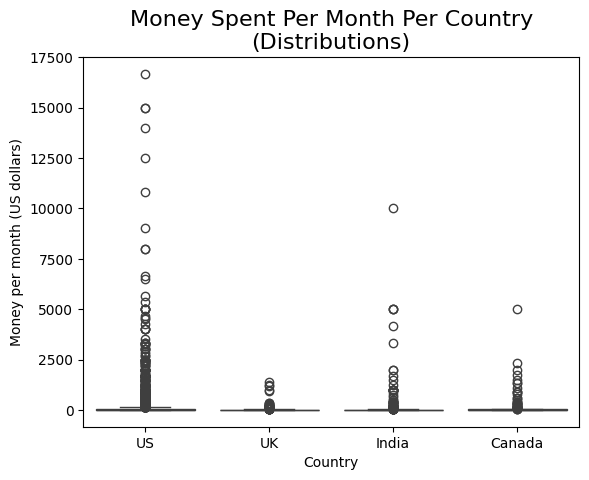

In [17]:
only_4 = interest_no_null[interest_no_null['CountryLive'].isin(['United States of America','United Kingdom', 'India','Canada'])]

sns.boxplot( y = 'money_spend', x = 'CountryLive', data = only_4)
plt.title('Money Spent Per Month Per Country\n(Distributions)',
         fontsize = 16)
plt.ylabel('Money per month (US dollars)')
plt.xlabel('Country')
plt.xticks(range(4), ['US', 'UK', 'India', 'Canada']) # avoids tick labels overlap
plt.show()

We can see a few outliers in india, but i can we due to user attending multiple bootcamps which can be expensive.

### Let' analyze the outlier of india

In [18]:
indian_outliers = only_4[(only_4['money_spend'] >= 2500) & (only_4['CountryLive'] == 'India')]
indian_outliers

,Age,AttendedBootcamp,BootcampFinish,BootcampLoanYesNo,BootcampName,BootcampRecommend,ChildrenNumber,CityPopulation,CodeEventConferences,CodeEventDjangoGirls,...,YouTubeFunFunFunction,YouTubeGoogleDev,YouTubeLearnCode,YouTubeLevelUpTuts,YouTubeMIT,YouTubeMozillaHacks,YouTubeOther,YouTubeSimplilearn,YouTubeTheNewBoston,money_spend
1728,24.0,0.0,NaN,NaN,NaN,NaN,NaN,"between 100,000 and 1 million",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5000.000000
1755,20.0,0.0,NaN,NaN,NaN,NaN,NaN,more than 1 million,NaN,NaN,...,NaN,NaN,1.0,NaN,1.0,NaN,NaN,NaN,NaN,3333.333333
7989,28.0,0.0,NaN,NaN,NaN,NaN,NaN,"between 100,000 and 1 million",1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5000.000000
8126,22.0,0.0,NaN,NaN,NaN,NaN,NaN,more than 1 million,NaN,NaN,...,NaN,1.0,NaN,NaN,1.0,NaN,NaN,NaN,1.0,5000.000000
13398,19.0,0.0,NaN,NaN,NaN,NaN,NaN,more than 1 million,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10000.000000
15587,27.0,0.0,NaN,NaN,NaN,NaN,NaN,more than 1 million,NaN,NaN,...,NaN,1.0,1.0,NaN,1.0,NaN,NaN,NaN,NaN,4166.666667


It's seem like neither of the participant attened bootcamp, so it is harder to justify the expenses.

In [19]:
# Remove the outliers of india
only_4 = only_4.drop(indian_outliers.index)

In [20]:
# Examine the extreme outliers for the US
us_outliers = only_4[
    (only_4['CountryLive'] == 'United States of America') & 
    (only_4['money_spend'] >= 6000)]

us_outliers

,Age,AttendedBootcamp,BootcampFinish,BootcampLoanYesNo,BootcampName,BootcampRecommend,ChildrenNumber,CityPopulation,CodeEventConferences,CodeEventDjangoGirls,...,YouTubeFunFunFunction,YouTubeGoogleDev,YouTubeLearnCode,YouTubeLevelUpTuts,YouTubeMIT,YouTubeMozillaHacks,YouTubeOther,YouTubeSimplilearn,YouTubeTheNewBoston,money_spend
718,26.0,1.0,0.0,0.0,The Coding Boot Camp at UCLA Extension,1.0,NaN,more than 1 million,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8000.000000
1222,32.0,1.0,0.0,0.0,The Iron Yard,1.0,NaN,"between 100,000 and 1 million",NaN,NaN,...,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,6500.000000
3184,34.0,1.0,1.0,0.0,We Can Code IT,1.0,NaN,more than 1 million,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9000.000000
3930,31.0,0.0,NaN,NaN,NaN,NaN,NaN,"between 100,000 and 1 million",NaN,NaN,...,1.0,1.0,1.0,1.0,1.0,NaN,various conf presentations,NaN,NaN,10833.333333
6805,46.0,1.0,1.0,1.0,Sabio.la,0.0,NaN,"between 100,000 and 1 million",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15000.000000
7198,32.0,0.0,NaN,NaN,NaN,NaN,NaN,more than 1 million,1.0,NaN,...,NaN,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,14000.000000
7505,26.0,1.0,0.0,1.0,Codeup,0.0,NaN,more than 1 million,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,6666.666667
9778,33.0,1.0,0.0,1.0,Grand Circus,1.0,NaN,"between 100,000 and 1 million",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8000.000000
16650,29.0,0.0,NaN,NaN,NaN,NaN,2.0,more than 1 million,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,16666.666667
16997,27.0,0.0,NaN,NaN,NaN,NaN,1.0,more than 1 million,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12500.000000


Out of these 11 extreme outliers, six people attended bootcamps, which justify the large sums of money spent on learning. For the other five, it's hard to figure out from the data where they could have spent that much money on learning. Consequently, we'll remove those rows where participants reported thay they spend $6000 each month, but they have never attended a bootcamp.

In [21]:
# Remove the respondents who didn't attendent a bootcamp
no_bootcamp = only_4[
    (only_4['CountryLive'] == 'United States of America') & 
    (only_4['money_spend'] >= 6000) &
    (only_4['AttendedBootcamp'] == 0)
]

only_4 = only_4.drop(no_bootcamp.index)


# Remove the respondents that had been programming for less than 3 months
less_than_3_months = only_4[
    (only_4['CountryLive'] == 'United States of America') & 
    (only_4['money_spend'] >= 6000) &
    (only_4['MonthsProgramming'] <= 3)
]

only_4 = only_4.drop(less_than_3_months.index)

In [22]:
# Examine the extreme outliers for Canada
canada_outliers = only_4[
    (only_4['CountryLive'] == 'Canada') & 
    (only_4['money_spend'] > 4500)]

canada_outliers

,Age,AttendedBootcamp,BootcampFinish,BootcampLoanYesNo,BootcampName,BootcampRecommend,ChildrenNumber,CityPopulation,CodeEventConferences,CodeEventDjangoGirls,...,YouTubeFunFunFunction,YouTubeGoogleDev,YouTubeLearnCode,YouTubeLevelUpTuts,YouTubeMIT,YouTubeMozillaHacks,YouTubeOther,YouTubeSimplilearn,YouTubeTheNewBoston,money_spend
13659,24.0,1.0,0.0,0.0,Bloc.io,1.0,NaN,more than 1 million,1.0,NaN,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,5000.0


The  participant had been programming for no more than two months when he completed the survey. He seems to have paid a large sum of money in the beginning to enroll in a bootcamp, and then he probably didn't spend anything for the next couple of months after the survey.

In [23]:
# Remove the extreme outliers for Canada
only_4 = only_4.drop(canada_outliers.index)

In [24]:
# Recompute mean sum of money spent by students each month
only_4.groupby('CountryLive').mean(numeric_only=True)['money_spend']

CountryLive
Canada                       93.065400
India                        65.758763
United Kingdom               45.534443
United States of America    142.654608
Name: money_spend, dtype: float64

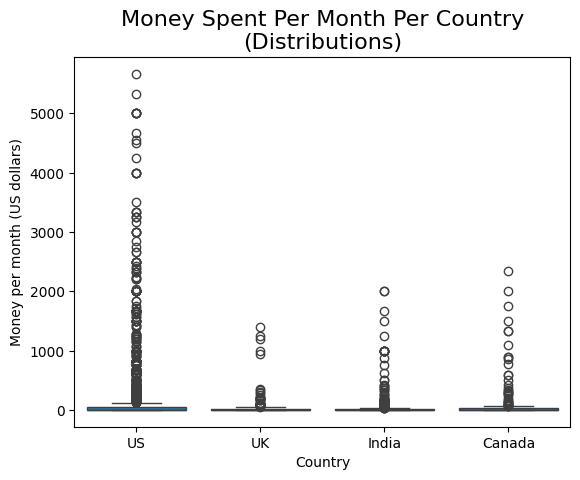

In [25]:

sns.boxplot( y = 'money_spend', x = 'CountryLive', data = only_4)
plt.title('Money Spent Per Month Per Country\n(Distributions)',
         fontsize = 16)
plt.ylabel('Money per month (US dollars)')
plt.xlabel('Country')
plt.xticks(range(4), ['US', 'UK', 'India', 'Canada']) # avoids tick labels overlap
plt.show()

## Choosing the Two Best Markets

In [26]:
# Frequency table for the 'CountryLive' column
only_4['CountryLive'].value_counts(normalize = True) * 100

CountryLive
United States of America    74.967908
India                       11.732991
United Kingdom               7.163030
Canada                       6.136072
Name: proportion, dtype: float64

From the anaysis, we can conclude that USA will be the first priority to advertise the product as participant spent aroud `142$` every month in courses with `75%` respondent in the survey.

For second choice we might choose from either Canada or India. As India provide a large potential market with around `11%` participant. it might be effective to advertise courses in india as second market. Canada participant spend more `93$` per month which give it an advantage over india.

We can also advertise in all three  country if we split the marketing budget based on the average expenditure of each country participant.

One possible combination will be US(`50%`) , India(`30%`), and Canada(`20%`).

## Conclusion

In this project, we analyzed survey data from new coders to find the best two markets to advertise in. The only solid conclusion we reached is that the US would be a good market to advertise in.

For the second best market, it wasn't clear-cut what to choose between India and Canada. We decided to send the results to the marketing team so they can use their domain knowledge to take the best decision.